<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting QFT2001 3D evolution: L=64, N_int=100, steps= 1000
t=   0  var_x=1.598e-06  vac_E=6.543e-05  max_amp=1.675e-02
t=  10  var_x=2.322e-06  vac_E=6.806e-05  max_amp=2.008e-02
t=  20  var_x=1.276e-06  vac_E=3.099e-05  max_amp=1.493e-02
t=  30  var_x=8.721e-07  vac_E=2.094e-05  max_amp=1.265e-02
t=  40  var_x=7.260e-07  vac_E=1.751e-05  max_amp=1.147e-02
t=  50  var_x=6.708e-07  vac_E=1.629e-05  max_amp=1.084e-02
t=  60  var_x=6.493e-07  vac_E=1.586e-05  max_amp=1.096e-02
t=  70  var_x=6.407e-07  vac_E=1.572e-05  max_amp=1.057e-02
t=  80  var_x=6.372e-07  vac_E=1.566e-05  max_amp=1.081e-02
t=  90  var_x=6.359e-07  vac_E=1.564e-05  max_amp=1.067e-02
t= 100  var_x=6.351e-07  vac_E=1.563e-05  max_amp=1.071e-02
t= 110  var_x=6.347e-07  vac_E=1.562e-05  max_amp=1.072e-02
t= 120  var_x=6.346e-07  vac_E=1.563e-05  max_amp=1.061e-02
t= 130  var_x=6.345e-07  vac_E=1.563e-05  max_amp=1.050e-02
t= 140  var_x=6.341e-07  vac_E=1.562e-05  max_amp=1.043e-02
t= 150  var_x=6.341e-07  vac_E=1.563e-05

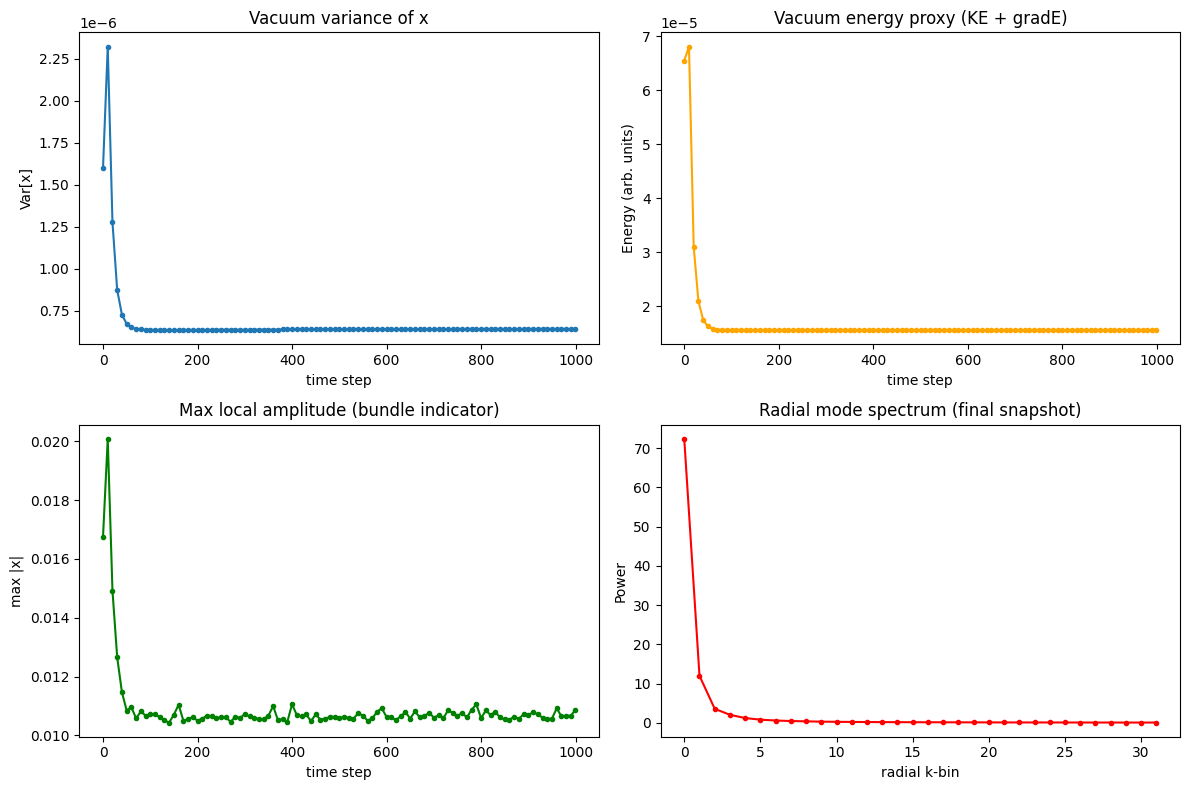


--- QFT2001 qualitative checks ---
Final vacuum variance: 6.411340926393063e-07
Final vacuum energy proxy: 1.5628921858799705e-05
Final max local amplitude: 0.01086089551342864
Mode spectra samples: 101 snapshots


In [2]:
# QFT2001 — Quantum Genesis (3D, 64³, N=100) — stable version
# Colab-ready, single block, no cross-cell dependencies.

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Core parameters
# -----------------------------
L = 64                  # spatial size: 64³
N_int = 100             # internal harmonic dimension

# Stability-tuned parameters
lambda_c = 0.02         # smaller effective coupling (acts like dt * Laplacian)
gamma = 0.10            # stronger damping
noise_amp = 1e-4        # gentler vacuum noise
n_steps = 1000          # total time steps

save_every = 10         # diagnostics cadence

rng = np.random.default_rng(1234)

# -----------------------------
# 2. Lattice indexing helpers
# -----------------------------
shape_field = (L, L, L, N_int)

def laplacian_3d_periodic(field):
    """
    3D periodic Laplacian over the first three axes.
    field: (L, L, L, N_int)
    returns: same shape
    """
    xp = np.roll(field, +1, axis=0)
    xm = np.roll(field, -1, axis=0)
    yp = np.roll(field, +1, axis=1)
    ym = np.roll(field, -1, axis=1)
    zp = np.roll(field, +1, axis=2)
    zm = np.roll(field, -1, axis=2)
    lap = (xp + xm + yp + ym + zp + zm - 6.0 * field)
    return lap

# -----------------------------
# 3. Initialize fields
# -----------------------------
# Use float64 for more headroom
x = 1e-3 * rng.standard_normal(size=shape_field).astype(np.float64)
v = 1e-3 * rng.standard_normal(size=shape_field).astype(np.float64)

# -----------------------------
# 4. Diagnostics storage
# -----------------------------
times = []
vacuum_var = []
vacuum_energy = []
mode_spectra = []
max_local_amp = []

# -----------------------------
# 5. Helper: compute diagnostics
# -----------------------------
def compute_diagnostics(t, x, v):
    var_x = np.var(x)

    ke = np.mean(v**2)
    lap_x = laplacian_3d_periodic(x)
    ge = np.mean(lap_x**2)
    vac_E = ke + ge

    amp = np.sqrt(np.sum(x**2, axis=-1))  # (L, L, L)
    max_amp = np.max(amp)

    comp = x[..., 0]
    fft3 = np.fft.fftn(comp)
    power3 = np.abs(fft3)**2

    kx = np.fft.fftfreq(L)
    ky = np.fft.fftfreq(L)
    kz = np.fft.fftfreq(L)
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    kr = np.sqrt(KX**2 + KY**2 + KZ**2)

    n_bins = L // 2
    bins = np.linspace(0, np.max(kr), n_bins + 1)
    radial_power = np.zeros(n_bins, dtype=np.float64)
    counts = np.zeros(n_bins, dtype=np.int64)

    kr_flat = kr.ravel()
    p_flat = power3.ravel()
    inds = np.digitize(kr_flat, bins) - 1
    valid = (inds >= 0) & (inds < n_bins)
    for i, p in zip(inds[valid], p_flat[valid]):
        radial_power[i] += p
        counts[i] += 1
    counts[counts == 0] = 1
    radial_power /= counts

    return var_x, vac_E, radial_power, max_amp

# -----------------------------
# 6. Main time evolution loop
# -----------------------------
print("Starting QFT2001 3D evolution: L=64, N_int=100, steps=", n_steps)

for t in range(n_steps):
    lap_x = laplacian_3d_periodic(x)
    eta = noise_amp * rng.standard_normal(size=shape_field).astype(np.float64)

    # Stable update: small lambda_c, stronger gamma
    v = v + lambda_c * lap_x - gamma * v + eta
    x = x + v

    if t % save_every == 0 or t == n_steps - 1:
        var_x, vac_E, radial_power, max_amp = compute_diagnostics(t, x, v)
        times.append(t)
        vacuum_var.append(var_x)
        vacuum_energy.append(vac_E)
        mode_spectra.append(radial_power)
        max_local_amp.append(max_amp)
        print(f"t={t:4d}  var_x={var_x:.3e}  vac_E={vac_E:.3e}  max_amp={max_amp:.3e}")

print("Evolution complete.")

times = np.array(times)
vacuum_var = np.array(vacuum_var)
vacuum_energy = np.array(vacuum_energy)
mode_spectra = np.array(mode_spectra)
max_local_amp = np.array(max_local_amp)

# -----------------------------
# 7. Basic plots
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(times, vacuum_var, '-o', ms=3)
axs[0, 0].set_title("Vacuum variance of x")
axs[0, 0].set_xlabel("time step")
axs[0, 0].set_ylabel("Var[x]")

axs[0, 1].plot(times, vacuum_energy, '-o', ms=3, color='orange')
axs[0, 1].set_title("Vacuum energy proxy (KE + gradE)")
axs[0, 1].set_xlabel("time step")
axs[0, 1].set_ylabel("Energy (arb. units)")

axs[1, 0].plot(times, max_local_amp, '-o', ms=3, color='green')
axs[1, 0].set_title("Max local amplitude (bundle indicator)")
axs[1, 0].set_xlabel("time step")
axs[1, 0].set_ylabel("max |x|")

if mode_spectra.shape[0] > 0:
    final_spec = mode_spectra[-1]
    axs[1, 1].plot(final_spec, '-o', ms=3, color='red')
    axs[1, 1].set_title("Radial mode spectrum (final snapshot)")
    axs[1, 1].set_xlabel("radial k-bin")
    axs[1, 1].set_ylabel("Power")

plt.tight_layout()
plt.show()

# -----------------------------
# 8. Quick qualitative checks (printed)
# -----------------------------
print("\n--- QFT2001 qualitative checks ---")
print("Final vacuum variance:", vacuum_var[-1])
print("Final vacuum energy proxy:", vacuum_energy[-1])
print("Final max local amplitude:", max_local_amp[-1])
print("Mode spectra samples:", mode_spectra.shape[0], "snapshots")
